In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fusicfenta/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [60]:
cd /root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1


In [61]:
ls

dataset/


In [62]:
cd dataset

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset


In [63]:
ls

logs/  single_prediction/  test_set/  training_set/


In [64]:
cd training_set/

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset/training_set


In [65]:
ls

cats/  dogs/


In [66]:
cd ..

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset


In [67]:
import tensorflow as tf
import os

In [68]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [69]:
import cv2
import imghdr

In [70]:
training_set = tf.keras.utils.image_dataset_from_directory('training_set')

Found 8000 files belonging to 2 classes.


In [71]:
data_iterator = training_set.as_numpy_iterator()

In [72]:
batch = data_iterator.next()
len(batch)


2

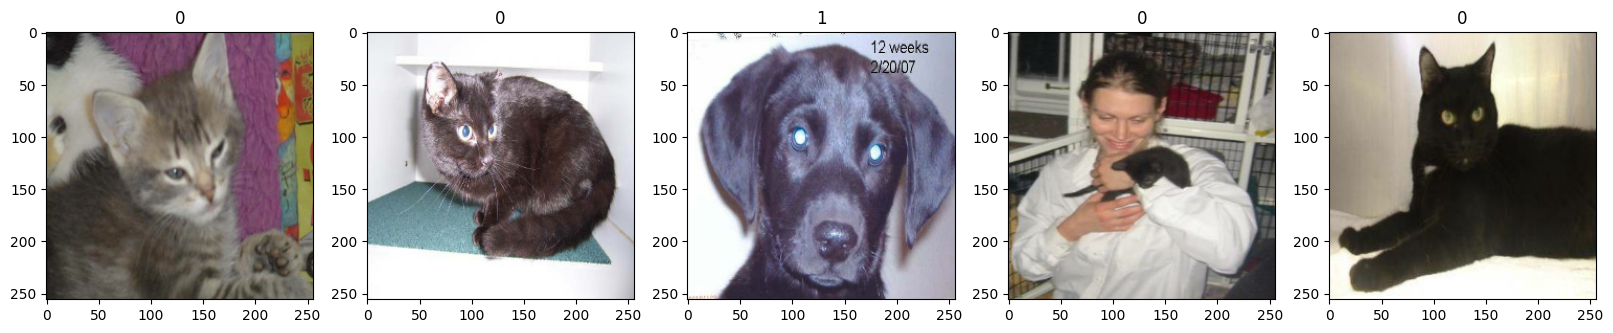

In [73]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [74]:
data = training_set.map(lambda x,y: (x/255, y))

In [75]:
training_set.as_numpy_iterator().next()



(array([[[[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         [[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         [[255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          ...,
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ],
          [255.       , 255.       , 255.       ]],
 
         ...,
 
         [[2

In [76]:

train_size = int(len(data)*.7) #70% train

val_size = int(len(data)*.2) #20% validation

test_size = int(len(data)*.1)#10% test
train = data.take(train_size)

val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,584,961 (112.86 MB)

 Trainable params: 29,584,961 (112.86 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
logdir = 'logs'

In [82]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.9975 - loss: 0.0099 - val_accuracy: 0.7337 - val_loss: 1.6997
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.9939 - loss: 0.0241 - val_accuracy: 0.7369 - val_loss: 1.6277
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9955 - loss: 0.0226 - val_accuracy: 0.7219 - val_loss: 1.9871
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 131ms/step - accuracy: 0.9948 - loss: 0.0181 - val_accuracy: 0.7344 - val_loss: 1.7155
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.9973 - loss: 0.0117 - val_accuracy: 0.7369 - val_loss: 2.0160
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9964 - loss: 0.0131 - val_accuracy: 0.7362 - val_loss: 1.6160
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.9970 - loss: 0.0120 - val_accuracy: 0.7513 - val_loss: 1.7654
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.9950 - loss: 0

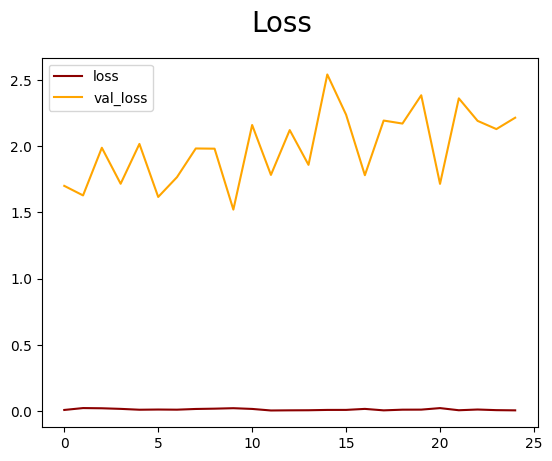

In [83]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()


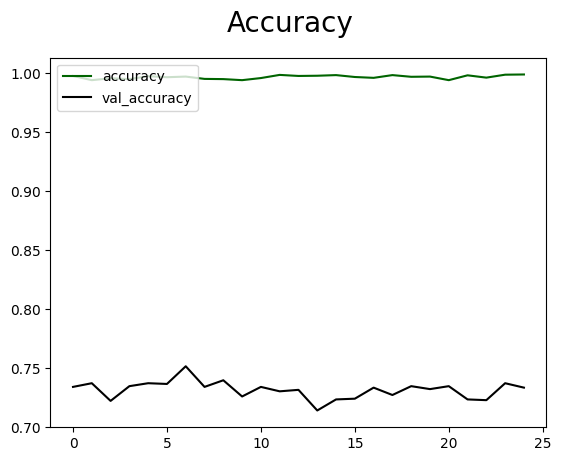

In [84]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [85]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [86]:
Pre.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.6902654767036438>

In [87]:
print(Re.result())

tf.Tensor(0.6109661, shape=(), dtype=float32)


In [88]:
print(Acc.result())

tf.Tensor(0.6825, shape=(), dtype=float32)


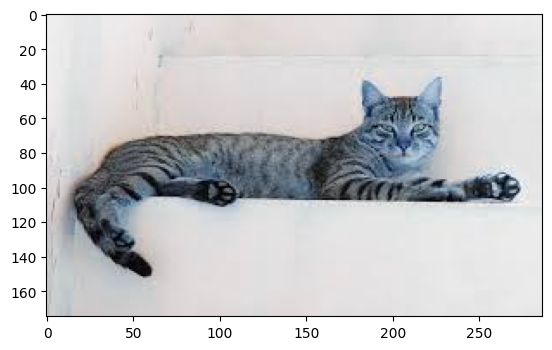

In [90]:
img=cv2.imread('/content/download.jpg')
plt.imshow(img)
plt.show()

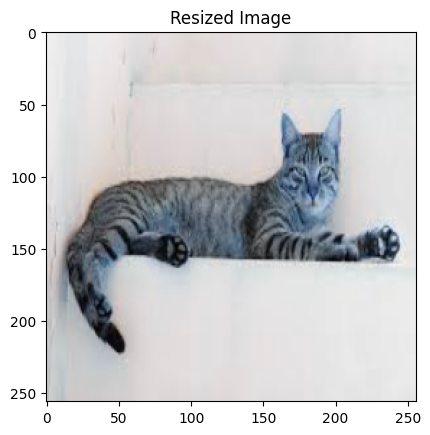

In [92]:
resize=tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.title('Resized Image')
plt.show()

In [94]:
yhat=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [95]:
yhat

array([[5.3735346e-07]], dtype=float32)

In [107]:
if yhat > 0.5:
    print(f'Predicted class is dog')
else:
    print(f'Predicted class is cat')

Predicted class is cat


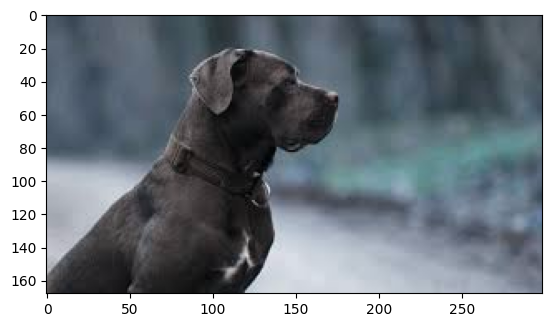

In [99]:
img =cv2.imread('/content/images (2).jpg')
plt.imshow(img)
plt.show()

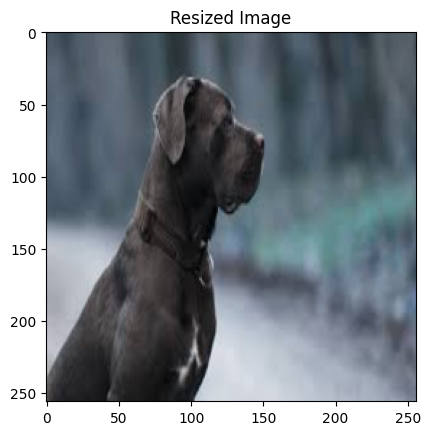

In [101]:
resize=tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.title('Resized Image')
plt.show()

In [102]:
yhat=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


In [103]:
yhat

array([[0.0001676]], dtype=float32)

In [110]:
if yhat > 0.5:
    print(f'Predicted class is cat')
else:
    print(f'Predicted class is dog')

Predicted class is dog


In [111]:
model.save(os.path.join('models','imageclassifier.h5'))